## ``Modern Portfolio Theory - Markowitz Efficient Frontiner``

##### ``Sandra Ranilla-Cortina``

In [ ]:
# Libraries
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns
import plotly as py
import plotly.graph_objs as go

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)

In [2]:
# NASDAQ (NDX) - Top 20 Stock Asset Prices

nasdaq_tck = [
    'AAPL',  # Apple
    'MSFT',  # Microsoft
    'GOOGL', # Alphabet (Google)
    'AMZN',  # Amazon
    'NVDA',  # NVIDIA
    'META',  # FB (Meta)
    'TSLA',  # Tesla
    'PYPL',  # PayPal
    'ADBE',  # Adobe
    'CSCO',  # Cisco Systems
    'AMD',   # Advanced Micro Devices
    'INTC',  # Intel
    'NFLX',  # Netflix
    'ZM',    # Zoom Video Communications
    'MRNA',  # Moderna
    'AMAT',  # Applied Materials
    'QCOM',  # Qualcomm
    'ASML',  # ASML
    'AVGO',   # Broadcom
    'SMCI',  # Super Micro Computer
]

# ndx_data = {}
# for ticker in nasdaq_tck:
#     stock_data = yf.download(ticker, start = '2024-01-01', end = '2025-01-01')
#     ndx_data[ticker] = stock_data.Close

# ndx_df = pd.concat(ndx_data, axis = 1)
# ndx_df.to_csv('../data/data_EfficientFrontier/nasdaq_data.csv', index = True)
ndx_df = pd.read_csv('../data/data_EfficientFrontier/nasdaq_data.csv', index_col = 0)
ndx_df = ndx_df.iloc[2:]
ndx_df = ndx_df.apply(pd.to_numeric, errors = 'coerce')
ndx_df.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,PYPL,ADBE,CSCO,AMD,INTC,NFLX,ZM,MRNA,AMAT,QCOM,ASML,AVGO,SMCI
2024-01-02,184.532089,367.380615,137.670929,149.929993,48.154346,344.972260,248.419998,61.459999,580.070007,48.586624,138.580002,47.168278,468.500000,69.150002,112.500000,152.821915,137.518112,711.210693,107.095505,28.545000
2024-01-03,183.150391,367.113159,138.418213,148.470001,47.555519,343.159180,238.449997,58.630001,571.789978,48.964691,135.320007,46.428196,470.260010,67.169998,108.580002,149.931198,134.938995,697.768555,104.451111,28.063999
2024-01-04,180.824356,364.478180,135.897369,144.570007,47.984398,345.799072,237.929993,58.450001,567.049988,48.547848,136.009995,46.250572,474.670013,66.900002,108.660004,147.812668,133.536621,694.713135,103.506828,28.879999
2024-01-05,180.098694,364.290009,135.239731,145.240005,49.083080,350.610687,237.490005,60.119999,564.599976,48.557541,138.580002,46.270309,474.059998,66.959999,111.120003,147.505768,134.085800,697.738892,103.533478,29.212999
2024-01-08,184.452545,371.164703,138.338501,149.100006,52.238186,357.295166,240.449997,61.740002,580.549988,48.916222,146.179993,47.809692,485.029999,68.389999,115.440002,150.040085,136.341324,715.099548,106.056496,32.028000


In [3]:
# Plot
def df_plot(df, title, ylabel):
    
    fig = plt.figure(figsize = (12, 4))
    ax = fig.gca()
    ax.set_facecolor('whitesmoke')
    for asset in df.columns.values:
        ax.plot(df.index, df[asset], label = asset, linewidth = 1)

    plt.grid(linestyle = '--')
    plt.title(title, fontsize = 12, fontweight = 'bold')

    plt.ylabel(ylabel, fontsize = 8)
    ax.tick_params(axis = 'y', labelsize = 8)

    plt.xlabel('Date', fontsize = 8)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval = 30))
    ax.tick_params(axis = 'x', labelsize = 8, rotation = 45)

    legend = plt.legend(prop = {'size': 8}, frameon = True, loc = 'upper left')
    legend.get_frame().set_linewidth(0.5)

    return

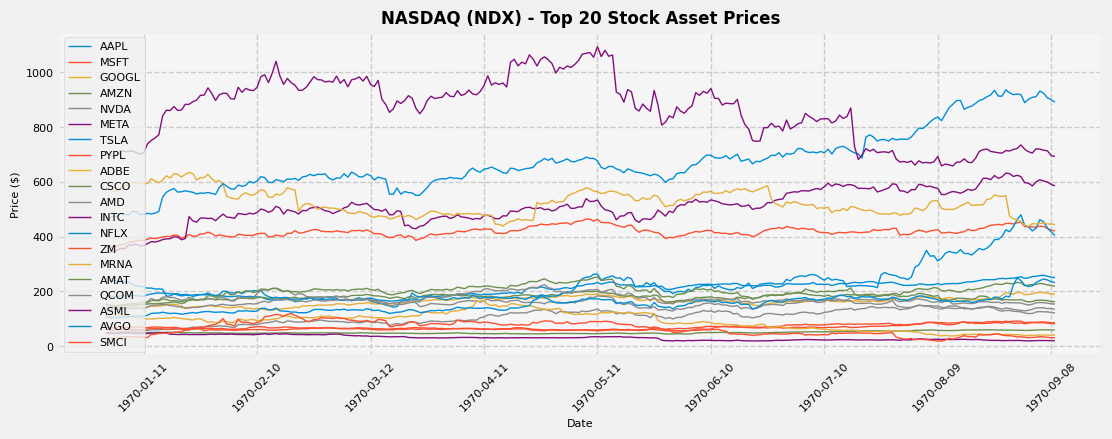

In [4]:
# Plot - Top 20 Stock Asset Prices
df_plot(df = ndx_df, title = 'NASDAQ (NDX) - Top 20 Stock Asset Prices', ylabel = 'Price ($)')

In [5]:
# Yield / Returns
def yield_return(df):
    yield_df = np.log(df) - np.log(df.shift(1))
    yield_df = yield_df.iloc[1:, :]
    return yield_df

ndx_yield_df = yield_return(ndx_df)
ndx_yield_df.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,PYPL,ADBE,CSCO,AMD,INTC,NFLX,ZM,MRNA,AMAT,QCOM,ASML,AVGO,SMCI
2024-01-03,-0.007516,-0.000728,0.005413,-0.009786,-0.012514,-0.005270,-0.040961,-0.047140,-0.014377,0.007751,-0.023805,-0.015815,0.003750,-0.029051,-0.035466,-0.019097,-0.018933,-0.019081,-0.025002,-0.016994
2024-01-04,-0.012781,-0.007203,-0.018380,-0.026619,0.008978,0.007663,-0.002183,-0.003075,-0.008324,-0.008550,0.005086,-0.003833,0.009334,-0.004028,0.000737,-0.014231,-0.010447,-0.004388,-0.009082,0.028662
2024-01-05,-0.004021,-0.000516,-0.004851,0.004624,0.022638,0.013819,-0.001851,0.028171,-0.004330,0.000200,0.018719,0.000427,-0.001286,0.000896,0.022387,-0.002078,0.004104,0.004346,0.000257,0.011465
2024-01-08,0.023887,0.018696,0.022655,0.026230,0.062299,0.018886,0.012387,0.026589,0.027858,0.007360,0.053391,0.032728,0.022877,0.021131,0.038140,0.017035,0.016682,0.024577,0.024077,0.091997
2024-01-09,-0.002266,0.002931,0.015083,0.015110,0.016833,-0.003435,-0.023097,-0.011239,0.009685,-0.010960,0.020851,-0.008290,-0.006080,-0.001170,-0.046636,-0.003503,0.006167,-0.006807,0.007083,0.070661


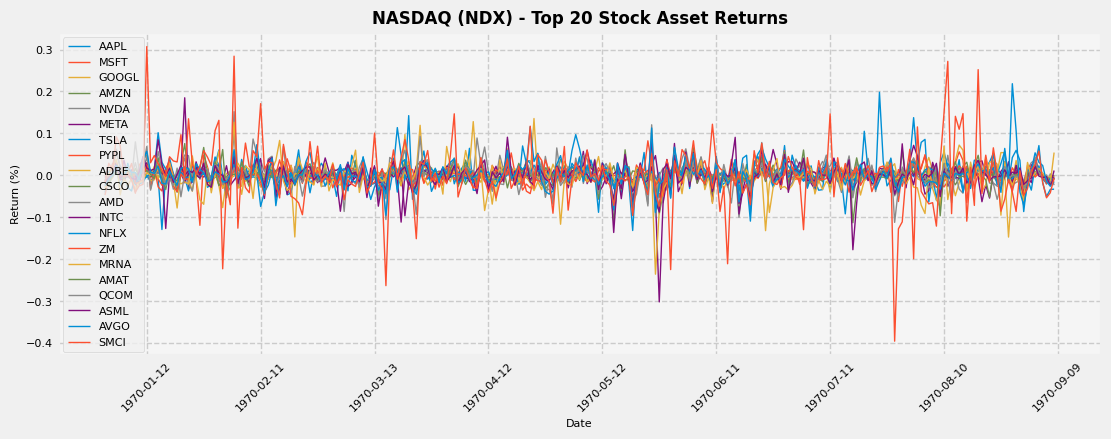

In [6]:
# Plot - Top 10 Stock Asset Returns
df_plot(df = ndx_yield_df, title = 'NASDAQ (NDX) - Top 20 Stock Asset Returns', ylabel = 'Return (%)')